## Etape - 1 Data prpreparation



In [67]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import json
from PIL import Image
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
import tensorflow as tf  # optionnel
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [68]:
csv_path = Path("..") / "train.csv"

try:
    mmc = pd.read_csv(csv_path)
    print("Lecture normale OK")
except pd.errors.ParserError:
    mmc = pd.read_csv(csv_path, engine="python", on_bad_lines="skip")

print("Shape:", mmc.shape)
mmc.head()

Shape: (29918, 3)


,ImageID,Labels,Caption
0,0.jpg,1,Woman in swim suit holding parasol on sunny day.
1,1.jpg,1 19,A couple of men riding horses on top of a gree...
2,2.jpg,1,They are brave for riding in the jungle on tho...
3,3.jpg,8 3 13,a black and silver clock tower at an intersect...
4,4.jpg,8 3 7,A train coming to a stop on the tracks out side.


All Labels: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 17, 18, 19]
{
  "1": 22755,
  "19": 1020,
  "8": 2203,
  "3": 4345,
  "13": 588,
  "7": 1217,
  "5": 1128,
  "4": 1271,
  "18": 1521,
  "15": 1928,
  "6": 1388,
  "9": 1041,
  "17": 1428,
  "10": 1458,
  "2": 1160,
  "16": 1097,
  "14": 252,
  "11": 597
}


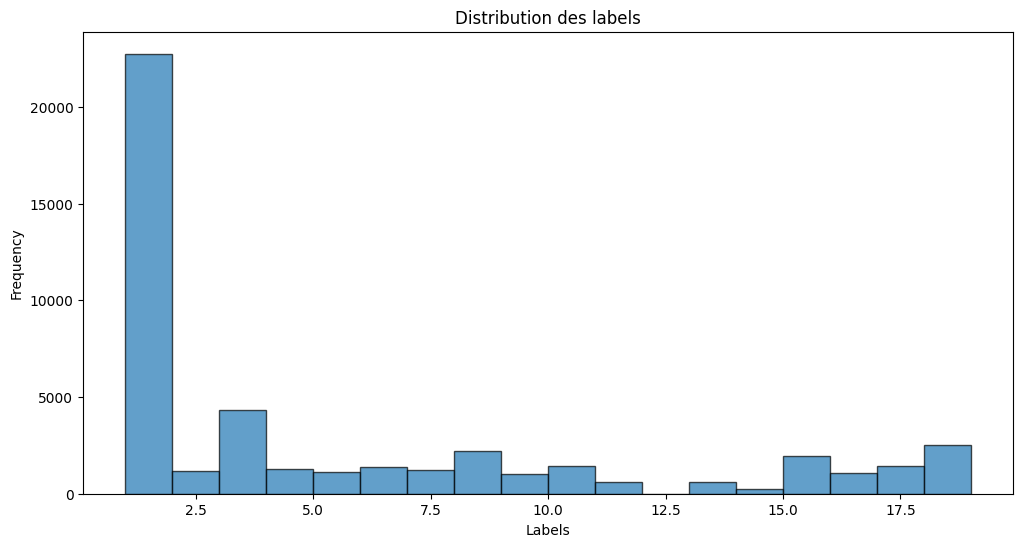

In [69]:
mmc["Labels_list"] = mmc["Labels"].astype(str).str.split().apply(lambda xs: [int(x) for x in xs])
all_labels = sorted({x for row in mmc["Labels_list"] for x in row})
print("All Labels:", all_labels)

labels_flat = [x for row in mmc["Labels_list"] for x in row]
count_dict = Counter(labels_flat)
print(json.dumps(count_dict, indent=2))

plt.figure(figsize=(12, 6))
plt.hist(labels_flat, bins=len(all_labels), edgecolor="black", alpha=0.7)
plt.xlabel("Labels")
plt.ylabel("Frequency")
plt.title("Distribution des labels")
plt.show()

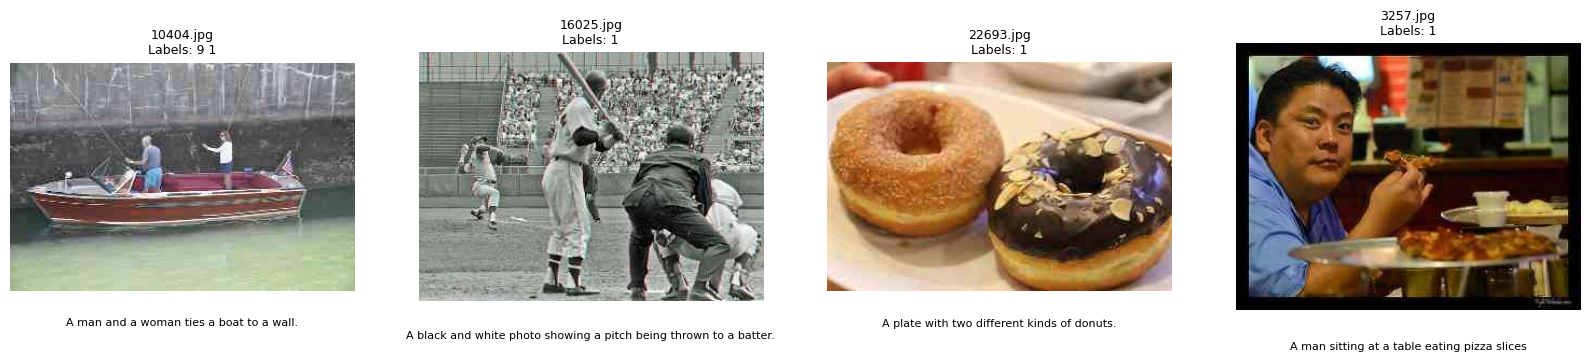

In [70]:

IMAGE_DIR = Path(r"C:\Users\mupps\Desktop\COMP5329S1A2Dataset\data")

num_samples = 4
sampled_df = mmc.sample(num_samples, random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(1, num_samples, figsize=(16, 5))

for i, row in sampled_df.iterrows():
    img_path = IMAGE_DIR / row["ImageID"]

    axes[i].axis("off")

    if img_path.exists():
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].set_title(
            f'{row["ImageID"]}\nLabels: {row["Labels"]}',
            fontsize=9
        )
        axes[i].text(
            0.5, -0.12, row["Caption"],
            ha="center", va="top",
            fontsize=8,
            wrap=True,
            transform=axes[i].transAxes
        )
    else:
        axes[i].text(
            0.5, 0.5, f"Image introuvable\n{row['ImageID']}",
            ha="center", va="center",
            fontsize=10,
            transform=axes[i].transAxes
        )

plt.tight_layout()
plt.show()

In [71]:
NUM_CLASSES = max(all_labels) + 1  # ou len(all_labels) si labels contigus

def multi_hot(label_list, n_classes):
    vec = np.zeros(n_classes, dtype=np.float32)
    for l in label_list:
        vec[l] = 1.0
    return vec

mmc["multi_hot"] = mmc["Labels_list"].apply(lambda x: multi_hot(x, NUM_CLASSES))

print("Exemple multi-hot pour la première ligne:")
print(f"  Labels: {mmc['Labels_list'].iloc[0]}")
print(f"  Vecteur: {mmc['multi_hot'].iloc[0]}")
print(f"  Shape vecteur: {mmc['multi_hot'].iloc[0].shape}")

Exemple multi-hot pour la première ligne:
  Labels: [1]
  Vecteur: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
  Shape vecteur: (20,)


In [72]:
train_df, temp_df = train_test_split(mmc, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Train:      {len(train_df)} exemples")
print(f"Validation: {len(val_df)} exemples")
print(f"Test:       {len(test_df)} exemples")

Train:      23934 exemples
Validation: 2992 exemples
Test:       2992 exemples


Longueur moyenne des captions: 10.5 mots
Max: 49 | Min: 7


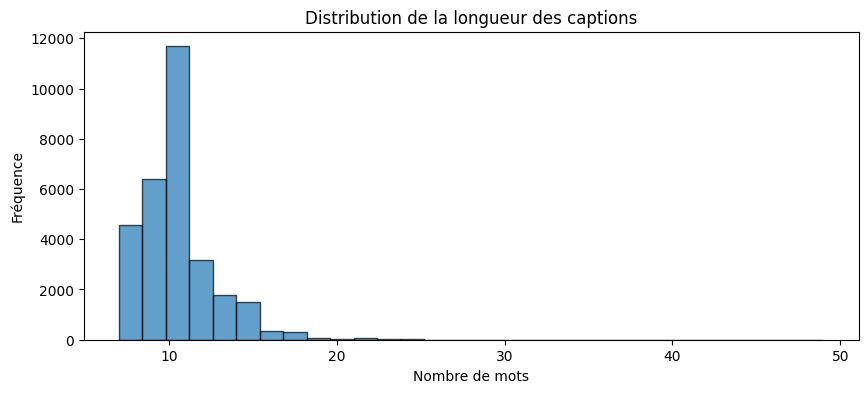

In [73]:
# Important pour la parti LSTM.
mmc["caption_len"] = mmc["Caption"].astype(str).str.split().str.len()

print(f"Longueur moyenne des captions: {mmc['caption_len'].mean():.1f} mots")
print(f"Max: {mmc['caption_len'].max()} | Min: {mmc['caption_len'].min()}")

plt.figure(figsize=(10, 4))
plt.hist(mmc["caption_len"], bins=30, edgecolor="black", alpha=0.7)
plt.xlabel("Nombre de mots")
plt.ylabel("Fréquence")
plt.title("Distribution de la longueur des captions")
plt.show()

In [74]:
# 1) Controle qualite global du dataset
expected_cols = {"ImageID", "Labels", "Caption"}
missing_cols = expected_cols - set(mmc.columns)

print("Colonnes manquantes:", missing_cols if missing_cols else "Aucune")
print("\nValeurs manquantes:")
print(mmc[["ImageID", "Labels", "Caption"]].isna().sum())

print("\nDoublons ImageID:", mmc["ImageID"].duplicated().sum())
print("Shape avant nettoyage:", mmc.shape)

Colonnes manquantes: Aucune

Valeurs manquantes:
ImageID    0
Labels     0
Caption    0
dtype: int64

Doublons ImageID: 0
Shape avant nettoyage: (29918, 6)


In [75]:
# 2) Nettoyage minimal des champs bruts
mmc["ImageID"] = mmc["ImageID"].astype(str).str.strip()
mmc["Labels"] = mmc["Labels"].astype(str).str.strip()
mmc["Caption"] = (
    mmc["Caption"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

# Retirer lignes invalides (vides)
mmc = mmc[
    (mmc["ImageID"] != "") &
    (mmc["Labels"] != "") &
    (mmc["Caption"] != "")
].copy()

print("Shape apres nettoyage:", mmc.shape)
mmc.head(5)

Shape apres nettoyage: (29918, 6)


,ImageID,Labels,Caption,Labels_list,multi_hot,caption_len
0,0.jpg,1,Woman in swim suit holding parasol on sunny day.,[1],"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",9
1,1.jpg,1 19,A couple of men riding horses on top of a gree...,"[1, 19]","[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",12
2,2.jpg,1,They are brave for riding in the jungle on tho...,[1],"[0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",11
3,3.jpg,8 3 13,a black and silver clock tower at an intersect...,"[8, 3, 13]","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, ...",12
4,4.jpg,8 3 7,A train coming to a stop on the tracks out side.,"[8, 3, 7]","[0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, ...",11


### Process label



In [76]:
# Process Labels (après split)
mlb = MultiLabelBinarizer()

# Important: fit uniquement sur train pour éviter la fuite
train_labels = mlb.fit_transform(train_df["Labels_list"])
val_labels   = mlb.transform(val_df["Labels_list"])
test_labels  = mlb.transform(test_df["Labels_list"])

print("Nb classes:", len(mlb.classes_))
print("Classes:", mlb.classes_)
print("Shape train:", train_labels.shape)
print("Shape val:", val_labels.shape)
print("Shape test:", test_labels.shape)

# Helper tensor (si tu utilises TensorFlow)
def to_float_tensor(y):
    return tf.convert_to_tensor(y, dtype=tf.float32)

y_train = to_float_tensor(train_labels)
y_val   = to_float_tensor(val_labels)
y_test  = to_float_tensor(test_labels)

Nb classes: 18
Classes: [ 1  2  3  4  5  6  7  8  9 10 11 13 14 15 16 17 18 19]
Shape train: (23934, 18)
Shape val: (2992, 18)
Shape test: (2992, 18)


### image data

Shape (H, W, C): (224, 224, 3)
Type: <dtype: 'float32'>
Min pixel: 0.007834566
Max pixel: 1.0
Nb canaux: 3


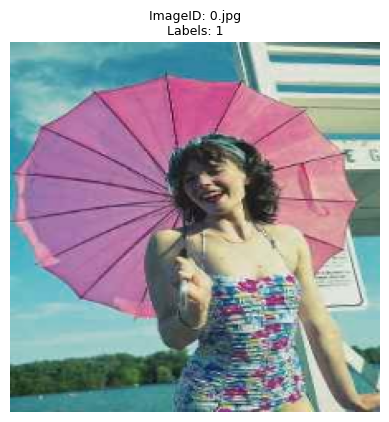

Canal R - min/max: 0.007834566 1.0
Canal G - min/max: 0.013024813 0.9936865
Canal B - min/max: 0.01771716 0.9854846


In [77]:
# composition de l'image
# A placer dans la partie image preprocessing
def load_image(image_id, target_size=(224, 224)):
    if tf.is_tensor(image_id):
        base_dir = str(IMAGE_DIR).replace("\\", "/")
        img_path = tf.strings.join([base_dir, image_id], separator="/")
        img = tf.io.read_file(img_path)
    else:
        img_path = IMAGE_DIR / str(image_id)
        img = tf.io.read_file(str(img_path))

    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, target_size)
    img = tf.cast(img, tf.float32) / 255.0
    return img


img = load_image(mmc["ImageID"].iloc[0])

print("Shape (H, W, C):", img.shape)
print("Type:", img.dtype)
print("Min pixel:", tf.reduce_min(img).numpy())
print("Max pixel:", tf.reduce_max(img).numpy())
print("Nb canaux:", img.shape[-1])

plt.imshow(img)
plt.axis("off")
plt.title(f"ImageID: {mmc['ImageID'].iloc[0]}\nLabels: {mmc['Labels'].iloc[0]}", fontsize=9)
plt.show()

arr = img.numpy()
print("Canal R - min/max:", arr[:, :, 0].min(), arr[:, :, 0].max())
print("Canal G - min/max:", arr[:, :, 1].min(), arr[:, :, 1].max())
print("Canal B - min/max:", arr[:, :, 2].min(), arr[:, :, 2].max())


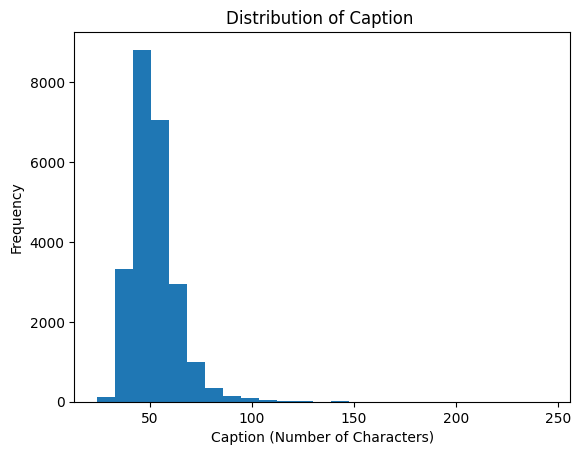

In [78]:
lengths = train_df['Caption'].dropna().astype(str).apply(len)
plt.figure()
plt.hist(lengths, bins=25)
plt.xlabel("Caption (Number of Characters)")
plt.ylabel("Frequency")
plt.title("Distribution of Caption ")
plt.show()

### Tokenizer

In [79]:
captions = train_df['Caption'].dropna().astype(str)
MAX_VOCAB_SIZE = 2000
CAPTION_MAX_LEN = 10
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(captions)

caption_vocab_size = len(tokenizer.word_index)

print("Taille du vocabulaire des captions:", caption_vocab_size)
print("Taille max du vocabulaire retenu pour le modele:", MAX_VOCAB_SIZE)
print("Longueur max des captions pour le modele:", CAPTION_MAX_LEN)

Taille du vocabulaire des captions: 6470
Taille max du vocabulaire retenu pour le modele: 2000
Longueur max des captions pour le modele: 10


### TextData

In [80]:
word_counts = tokenizer.word_counts
print(word_counts)
print(f"Nombre de mots uniques: {len(word_counts)}")

frequencies_word = np.array(list(word_counts.values()))
sorted_freqs_word = np.sort(frequencies_word)[::-1]


OrderedDict([('a', 42907), ('gray', 107), ('train', 1000), ('parked', 738), ('at', 1961), ('platform', 67), ('with', 4921), ('people', 2286), ('truck', 476), ('driving', 271), ('underneath', 47), ('traffic', 314), ('lights', 103), ('in', 7158), ('the', 7584), ('middle', 152), ('of', 8538), ('street', 1600), ('mascot', 4), ('stands', 205), ('next', 1901), ('to', 3115), ('audience', 16), ('as', 309), ('batter', 96), ('is', 3705), ('swinging', 191), ('black', 812), ('cat', 907), ('lays', 26), ('over', 476), ('computer', 225), ('keyboard', 59), ('on', 8890), ('desk', 160), ('man', 4398), ('water', 696), ('skis', 376), ('being', 160), ('pulled', 31), ('by', 642), ('boat', 327), ('young', 1071), ('holding', 1741), ('milk', 10), ('jug', 2), ('and', 4050), ('standing', 2236), ('skateboard', 594), ('little', 362), ('boy', 582), ('sitting', 2527), ('side', 562), ('door', 69), ('car', 396), ('looking', 468), ('zebra', 35), ('bunch', 158), ('towels', 4), ('clothes', 31), ('laying', 485), ('sand', 

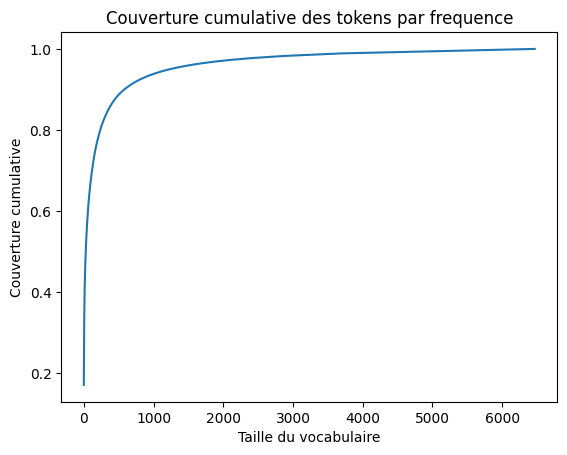

In [81]:
total_token_count = np.sum(sorted_freqs_word)
cumulative_counts = np.cumsum(sorted_freqs_word)
results = cumulative_counts / total_token_count

plt.plot(results)
plt.xlabel("Taille du vocabulaire")
plt.ylabel("Couverture cumulative")
plt.title("Couverture cumulative des tokens par frequence")
plt.show()

In [82]:
# Tokenizer deja entraine plus haut pour eviter une repetition.
effective_vocab_size = min(len(tokenizer.word_index) + 1, MAX_VOCAB_SIZE)
print("Vocabulaire effectif utilise par le tokenizer:", effective_vocab_size)

Vocabulaire effectif utilise par le tokenizer: 2000


In [83]:
def tokenize_text(text):
    sequences = tokenizer.texts_to_sequences([text])
    return pad_sequences(sequences, maxlen=CAPTION_MAX_LEN, padding='post', truncating='post')

In [84]:
print(tokenize_text(train_df['Caption'].iloc[15]).shape)
print(tokenize_text(train_df['Caption'].iloc[15]))

(1, 10)
[[   2    8 1805   77    5  118  131    2  335  120]]


### Multimodal Data

In [85]:
MULTIMODAL_IMAGE_SIZE = (224, 224)
MULTIMODAL_BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def encode_captions(series, tokenizer, max_len):
    seq = tokenizer.texts_to_sequences(series.astype(str).tolist())
    return pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

X_train_text = encode_captions(train_df["Caption"], tokenizer, CAPTION_MAX_LEN)
X_val_text = encode_captions(val_df["Caption"], tokenizer, CAPTION_MAX_LEN)
X_test_text = encode_captions(test_df["Caption"], tokenizer, CAPTION_MAX_LEN)

print('Shape texte train :', X_train_text.shape)
print('Shape texte val   :', X_val_text.shape)
print('Shape texte test  :', X_test_text.shape)

Shape texte train : (23934, 10)
Shape texte val   : (2992, 10)
Shape texte test  : (2992, 10)


In [86]:
def make_multimodal_dataset(df, text_inputs, labels, batch_size=32, shuffle=False):
    image_ids = df['ImageID'].astype(str).values
    captions = df['Caption'].astype(str).values

    dataset = tf.data.Dataset.from_tensor_slices(
        (image_ids, captions, text_inputs, labels.astype(np.float32))
    )

    def _load_example(image_id, caption, text_tokens, target):
        image = load_image(image_id, target_size=MULTIMODAL_IMAGE_SIZE)
        features = {
            'image': image,
            'text_tokens': tf.cast(text_tokens, tf.int32),
            'caption': caption,
        }
        return features, tf.cast(target, tf.float32)

    dataset = dataset.map(_load_example, num_parallel_calls=AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(df), reshuffle_each_iteration=True)

    dataset = dataset.batch(batch_size).prefetch(AUTOTUNE)
    return dataset

In [87]:
train_multimodal_ds = make_multimodal_dataset(
    train_df, X_train_text, train_labels, batch_size=MULTIMODAL_BATCH_SIZE, shuffle=True
)
val_multimodal_ds = make_multimodal_dataset(
    val_df, X_val_text, val_labels, batch_size=MULTIMODAL_BATCH_SIZE, shuffle=False
)
test_multimodal_ds = make_multimodal_dataset(
    test_df, X_test_text, test_labels, batch_size=MULTIMODAL_BATCH_SIZE, shuffle=False
)

sample_features, sample_labels = next(iter(train_multimodal_ds))

print(sample_features["image"].shape)
print(sample_features["text_tokens"].shape)
print(sample_labels.shape)

(32, 224, 224, 3)
(32, 10)
(32, 18)



Batch image shape : (32, 224, 224, 3)
Batch text shape  : (32, 10)
Batch label shape : (32, 18)
Type image        : <dtype: 'float32'>
Type text         : <dtype: 'int32'>
Type label        : <dtype: 'float32'>


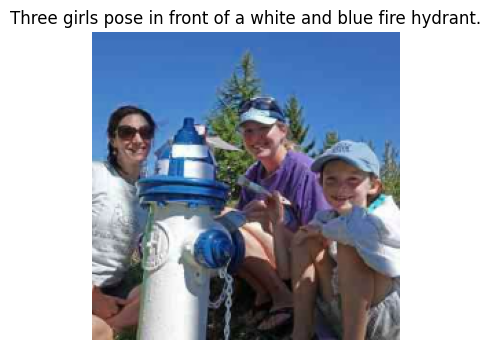

Tokens du premier exemple : [105 337 598   6  37   4   2  26   9  58]
Caption du premier exemple : Three girls pose in front of a white and blue fire hydrant.
Labels du premier exemple : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]


In [88]:
print('\nBatch image shape :', sample_features['image'].shape)
print('Batch text shape  :', sample_features['text_tokens'].shape)
print('Batch label shape :', sample_labels.shape)
print('Type image        :', sample_features['image'].dtype)
print('Type text         :', sample_features['text_tokens'].dtype)
print('Type label        :', sample_labels.dtype)

sample_idx = 0
plt.figure(figsize=(4, 4))
plt.imshow(sample_features['image'][sample_idx])
plt.axis('off')
plt.title(sample_features['caption'][sample_idx].numpy().decode('utf-8'))
plt.show()

print('Tokens du premier exemple :', sample_features['text_tokens'][sample_idx].numpy())
print('Caption du premier exemple :', sample_features['caption'][sample_idx].numpy().decode('utf-8'))
print('Labels du premier exemple :', sample_labels[sample_idx].numpy())

### Text Model